# 🛡️ Chapter 7: Support Vector Machines and Kernel Methods
**Book Reference:** *scikit-learn Cookbook, Third Edition*

---
## 1. Introduction
Support Vector Machines (SVM) are highly versatile models engineered for both linear and non-linear classification tasks. Their primary advantage lies in their mathematical capability to maximize the separation margin between classes, ensuring robust generalization performance on new, unseen data points.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_circles
from sklearn.svm import SVC

%matplotlib inline
np.random.seed(42)

## 2. Linear SVM and Maximum Margin
We begin by working with linearly separable data. The hyperparameter `C` regulates the penalty cost applied to misclassifications. A higher `C` value forces a narrower margin with stricter error tolerance, whereas a smaller `C` value allows a wider margin with increased tolerance for misplaced points.

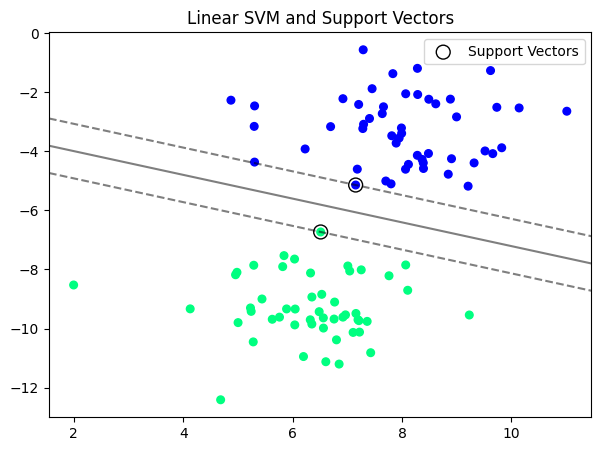

In [2]:
# Generate linearly separable data
X_lin, y_lin = make_blobs(n_samples=100, centers=2, random_state=6, cluster_std=1.2)

# Train a Linear SVM model
svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_lin, y_lin)

# Visualize the Decision Boundary and Margins
plt.figure(figsize=(7, 5))
plt.scatter(X_lin[:, 0], X_lin[:, 1], c=y_lin, s=30, cmap='winter')

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = svm_linear.decision_function(xy).reshape(XX.shape)

# Draw the decision boundaries and margins
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
# Highlight the Support Vectors
ax.scatter(svm_linear.support_vectors_[:, 0], svm_linear.support_vectors_[:, 1], s=100,
           linewidth=1, facecolors='none', edgecolors='k', label='Support Vectors')
plt.title('Linear SVM and Support Vectors')
plt.legend()
plt.show()

## 3. Kernel Trick (RBF) for Non-Linear Data
When facing circular or structurally complex layouts, a straight decision boundary will fail. We use the RBF (*Radial Basis Function*) kernel instead, which maps data into higher dimensions to construct an elegant, curved decision boundary.

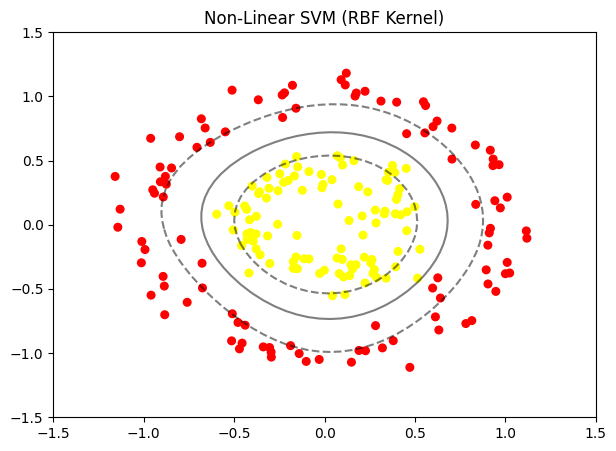

In [3]:
# Generate circular (non-linear) data
X_circ, y_circ = make_circles(n_samples=200, noise=0.1, factor=0.4, random_state=42)

# Train SVM using an RBF Kernel. The 'gamma' parameter controls the radius of influence for individual samples.
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_circ, y_circ)

plt.figure(figsize=(7, 5))
plt.scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, s=30, cmap='autumn')

ax = plt.gca()
xx = np.linspace(-1.5, 1.5, 50)
yy = np.linspace(-1.5, 1.5, 50)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = svm_rbf.decision_function(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
plt.title('Non-Linear SVM (RBF Kernel)')
plt.show()